In [21]:
import json
import matplotlib.pyplot as plt
import numpy as np
from typing import Any

def _load_jsonl_trials_with_meta(filepath: str) -> tuple[dict | None, list[dict]]:
    """
    jsonl_trials / jsonl_trials_dict を読み込み、
    先頭の {"__meta__": ...} があれば meta として分離して返す。
    それ以外は trial record として trials(list) に入れる。
    """
    meta = None
    trials: list[dict] = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if isinstance(rec, dict) and "__meta__" in rec and meta is None:
                m = rec.get("__meta__")
                meta = m if isinstance(m, dict) else None
                continue
            if isinstance(rec, dict):
                trials.append(rec)
    return meta, trials


def load_event_history(filepath: str, trial: int = 0) -> dict[str, list[int]]:
    """JSONLファイル（jsonl_trials / jsonl_trials_dict）から指定trialのイベント履歴を読み込む（互換維持＋meta行対応）"""
    meta, trials = _load_jsonl_trials_with_meta(filepath)

    if len(trials) == 0:
        raise ValueError("No trial records found in JSONL.")

    # --- trialレコードの選び方（互換性のための優先順位）---
    # 1) レコード側に "trial" があるなら、その値で引く（meta行が混ざっても安全）
    trial_map: dict[int, dict] = {}
    has_trial_field = True
    for rec in trials:
        if not isinstance(rec, dict) or "trial" not in rec:
            has_trial_field = False
            break
        try:
            t = int(rec["trial"])
        except Exception:
            has_trial_field = False
            break
        trial_map[t] = rec

    if has_trial_field and trial in trial_map:
        trial_data = trial_map[trial]
    else:
        # 2) 従来互換：trialを行インデックスとして扱う
        if trial < 0 or trial >= len(trials):
            raise IndexError(f"trial={trial} is out of range (0..{len(trials)-1})")
        trial_data = trials[trial]

    events = trial_data.get("events", {})

    # dict形式: {"name":[...], ...}
    if isinstance(events, dict):
        return {str(k): list(map(int, v)) for k, v in events.items()}

    # list形式: [["name",[...]], ...]
    if isinstance(events, list):
        out: dict[str, list[int]] = {}
        for e in events:
            if not (isinstance(e, (list, tuple)) and len(e) == 2):
                continue
            name, steps = e
            out[str(name)] = list(map(int, steps)) if steps is not None else []
        return out

    raise ValueError("Unsupported events format in JSONL (expected dict or list).")


def _format_sweep_from_meta(meta: dict | None, trial: int) -> str | None:
    """
    meta から trial に対応する sweep 確率表示文字列を作る。
    例: "sweep: foo=0.120, bar=0.350"
    """
    if not isinstance(meta, dict):
        return None

    sweep = meta.get("probability_sweep", None)
    if not isinstance(sweep, dict) or len(sweep) == 0:
        return None

    parts: list[str] = []
    for alias, info in sweep.items():
        if not isinstance(info, dict):
            continue
        probs = info.get("prob_by_trial", None)
        if not isinstance(probs, list):
            continue
        if 0 <= trial < len(probs):
            try:
                p = float(probs[trial])
            except Exception:
                continue
            parts.append(f"{alias}={p:.6g}")  # 互換のため固定桁にせず、短く

    if not parts:
        return None

    return "sweep: " + ", ".join(parts)


def plot_cumulative_events(
    event_source: Any,
    event_names: list[str] | None = None,
    figsize: tuple[int, int] = (12, 6),
    title: str = "Event Firing History",
    xlim: tuple[int, int] | None = None,
    *,
    trial: int = 0,
):
    """
    イベント発火の累積回数をプロット（互換性厳密維持＋meta sweepタイトル対応）

    互換動作（厳密）:
      - event_source が dict {event_name:[steps...]} の場合:
          * 従来通りそのdictを描画（trialは無視）
          * タイトルは引数titleをそのまま使う（変更しない）

    追加動作:
      - event_source が str（filepath）の場合:
          * JSONLから trial を読み込んで描画
          * 先頭に {"__meta__":...} があれば sweep確率を計算してタイトルに付加
    """
    # --- 入力の吸収（互換維持の要点）---
    meta = None
    if isinstance(event_source, str):
        # meta行がある場合にも安全に読む
        meta, _trials = _load_jsonl_trials_with_meta(event_source)
        event_dict = load_event_history(event_source, trial=trial)

        sweep_txt = _format_sweep_from_meta(meta, trial)
        if sweep_txt is None:
            auto_title = f"{title} (trial={trial})"
        else:
            auto_title = f"{title} (trial={trial} | {sweep_txt})"

    elif isinstance(event_source, dict):
        # ここは互換性のため「一切」挙動を変えない
        event_dict = event_source
        auto_title = title

    else:
        raise TypeError("event_source must be either dict or filepath (str).")

    fig, ax = plt.subplots(figsize=figsize)

    if event_names is None:
        event_names = list(event_dict.keys())

    for event_name in event_names:
        if event_name not in event_dict:
            print(f"Warning: '{event_name}' not found")
            continue

        steps = event_dict[event_name]
        if not steps:
            continue

        steps_sorted = np.sort(np.asarray(steps, dtype=np.int64))
        cumulative = np.arange(1, len(steps_sorted) + 1, dtype=np.int64)
        ax.step(steps_sorted, cumulative, where="post", label=event_name)

    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Firings")
    ax.set_title(auto_title)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.grid(True, alpha=0.3)

    if xlim is not None:
        ax.set_xlim(xlim)

    plt.tight_layout()
    plt.show()


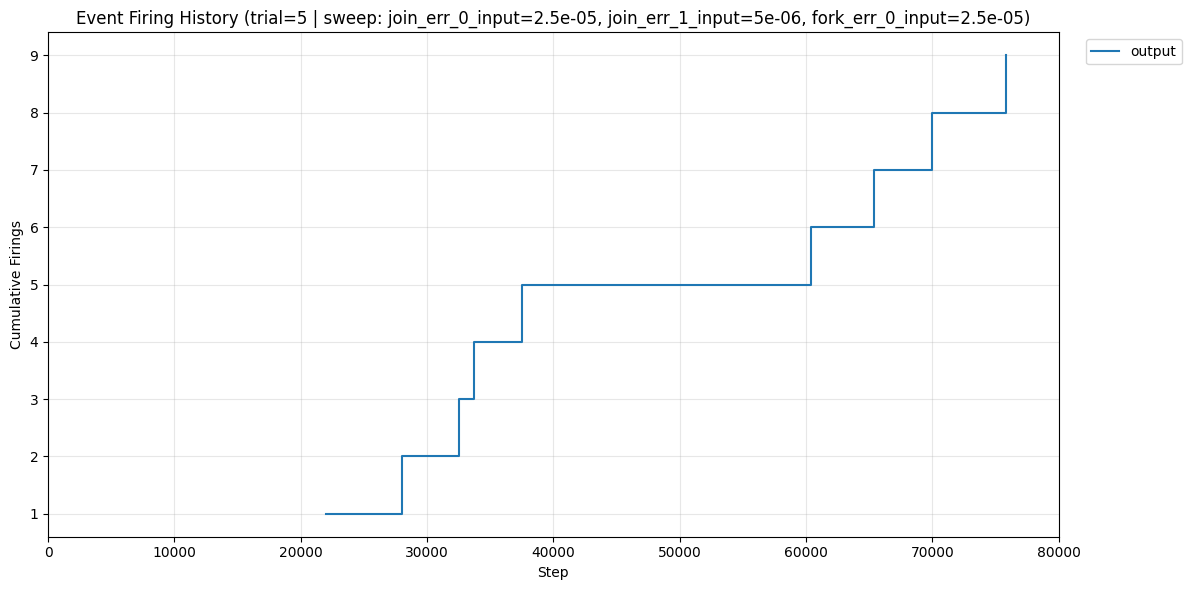

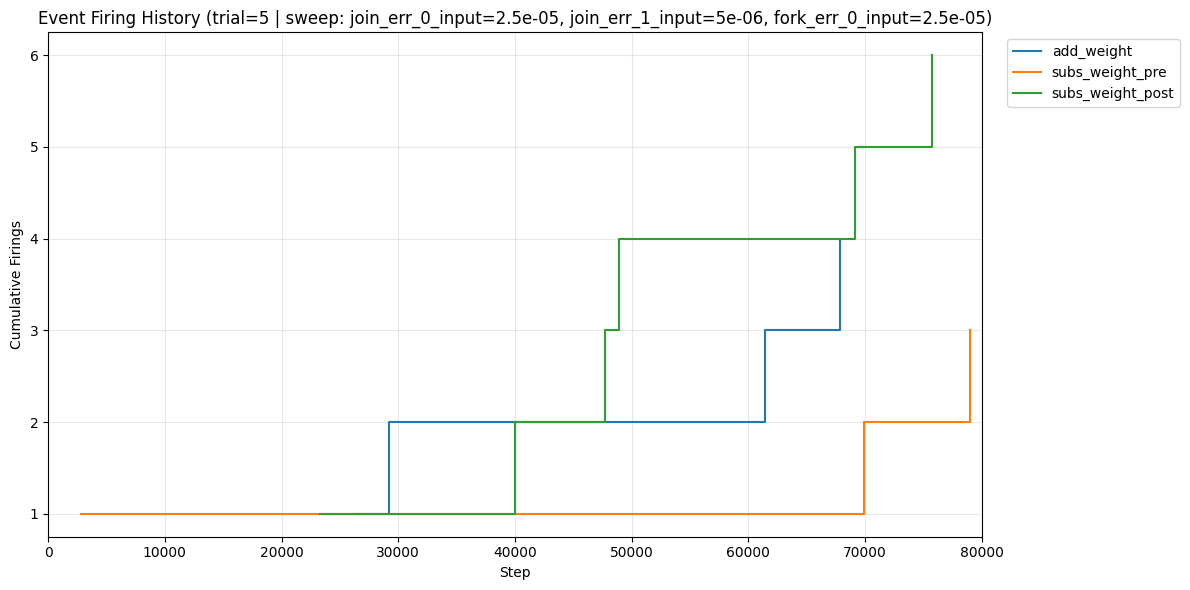

/var/folders/ss/qnbrzmmx6jjgm0jbvxb8r7v40000gn/T/ipykernel_94556/714357393.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))


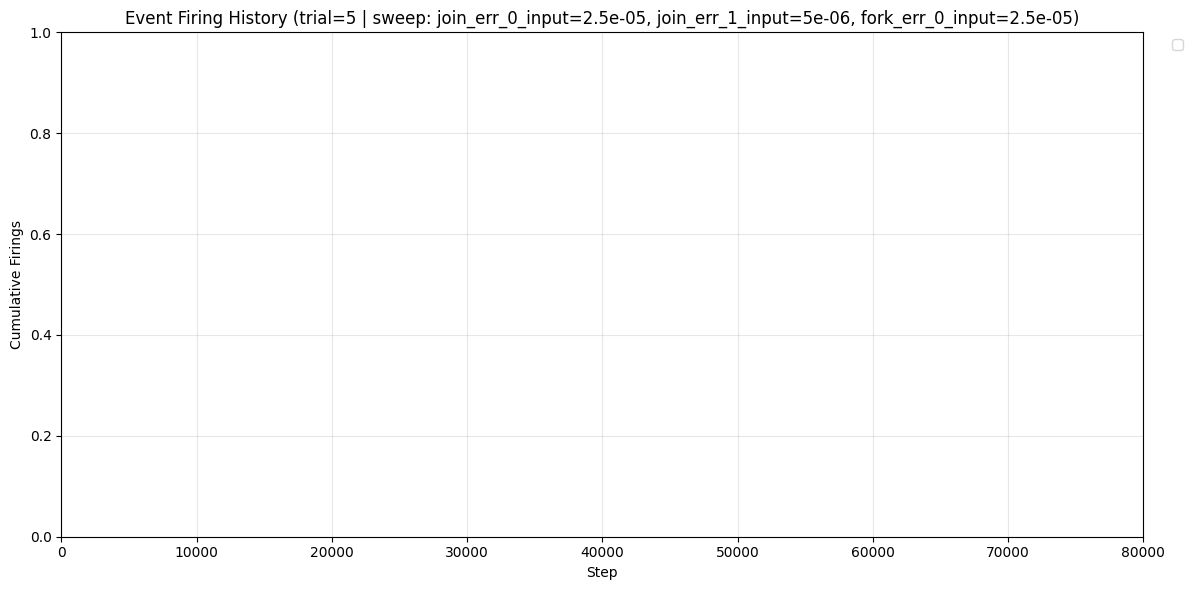

In [22]:
fine_name = "../jsonl/BNN/bnn.jsonl"
trial = 5
steps = 80_000

plot_cumulative_events(fine_name, event_names=["output"], xlim=(0, steps), trial=trial)
plot_cumulative_events(fine_name, event_names=["add_weight", "subs_weight_pre", "subs_weight_post"], xlim=(0, steps), trial=trial)
plot_cumulative_events(fine_name, event_names=["input_from_Pre-Neuron", "input_from_Post-Neuron"], xlim=(0, steps), trial=trial)

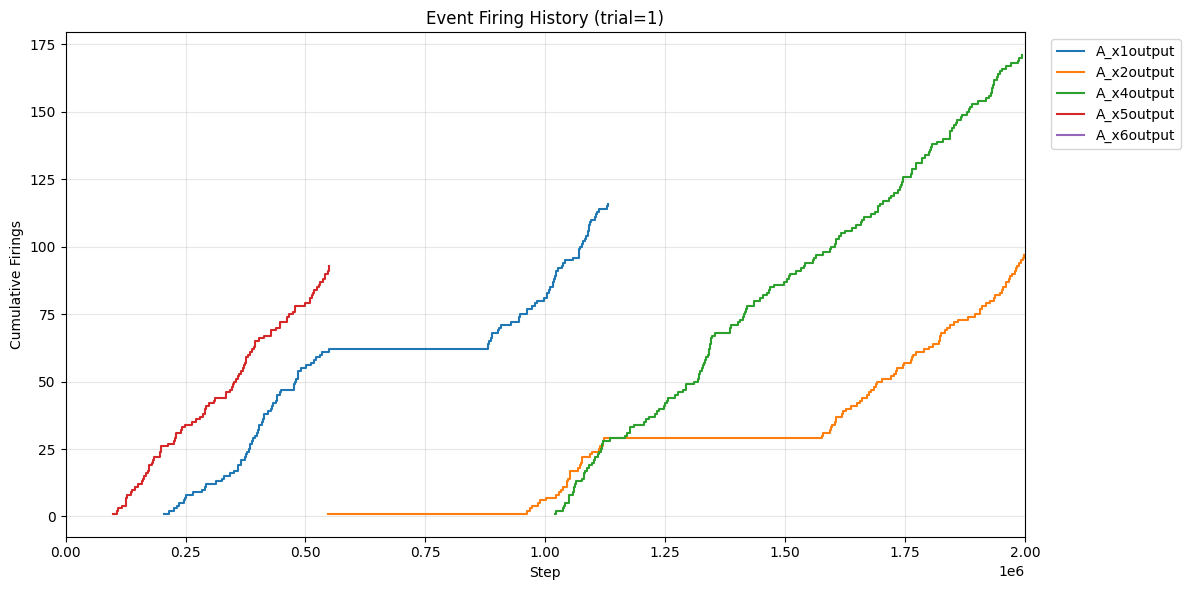

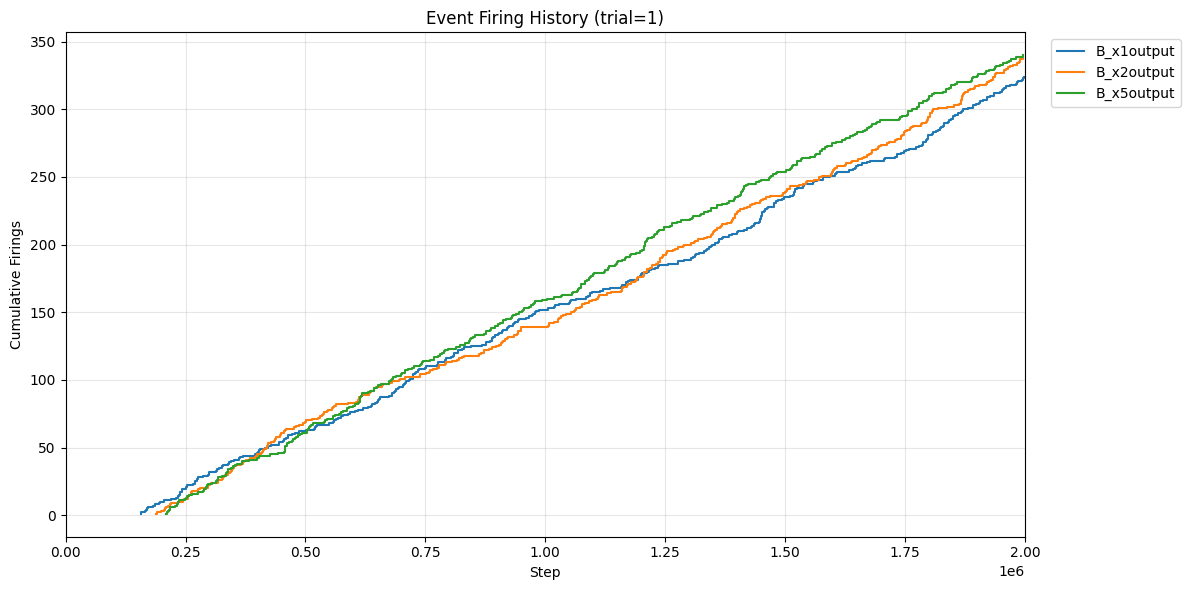

In [23]:
fine_name = "../jsonl/BCA-IP/10trials/BCA-IP.jsonl"
trial = 1
steps = 2_000_000

plot_cumulative_events(fine_name, event_names=["A_x1output", "A_x2output", "A_x3output", "A_x4output", "A_x5output", "A_x6output"
                                                ], xlim=(0, steps), trial=trial)
plot_cumulative_events(fine_name, event_names=["B_x1output", "B_x2output", "B_x3output", "B_x4output", "B_x5output", "B_x6output"
                                                ], xlim=(0, steps), trial=trial)